# Imports

In [1]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import joblib

# Model And Data Loading

In [2]:
# model = joblib.load('../models/random_forest.pkl')
model = joblib.load('../models/XGBoost.pkl')

X_test = pd.read_parquet('../data/processed/X_test.parquet')
y_test = pd.read_parquet('../data/processed/y_test.parquet').squeeze()

# Metrics

In [3]:
pred = model.predict(X_test)
proba = model.predict_proba(X_test)[:, 1]

In [4]:
print(classification_report(y_test, pred))
print('ROC-AUC: ', roc_auc_score(y_test, proba))

              precision    recall  f1-score   support

           0       0.80      0.78      0.79      2806
           1       0.73      0.75      0.74      2194

    accuracy                           0.77      5000
   macro avg       0.76      0.77      0.76      5000
weighted avg       0.77      0.77      0.77      5000

ROC-AUC:  0.8338277268855449


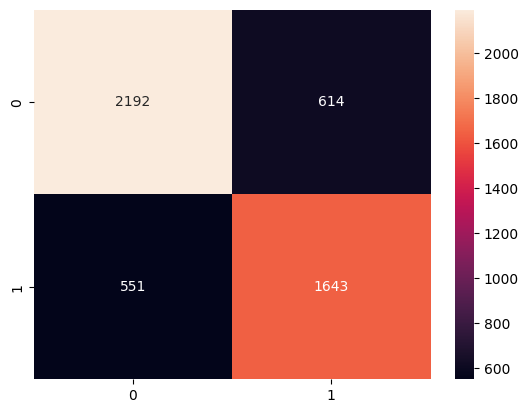

In [5]:
sns.heatmap(confusion_matrix(y_test, pred), annot=True, fmt='d')
plt.show()

In [6]:
confusion_matrix(y_test, pred)

array([[2192,  614],
       [ 551, 1643]])

# Feature Importance

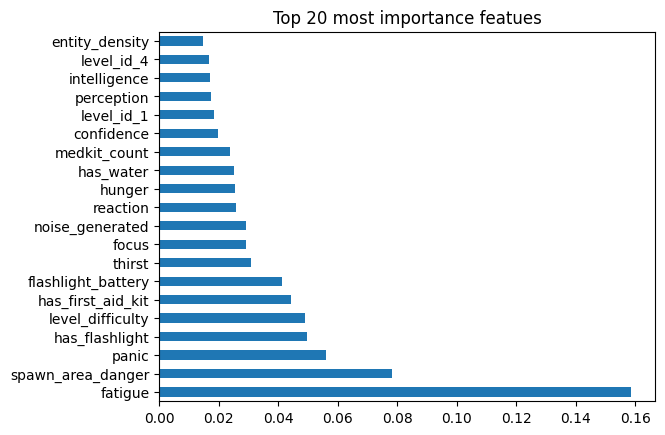

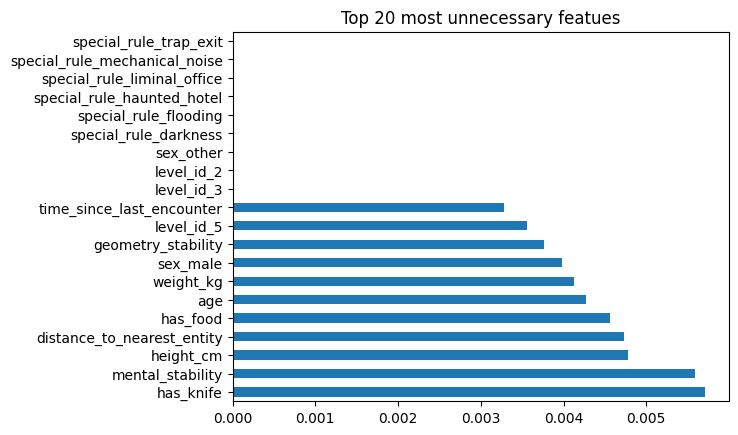

In [7]:
importances = pd.Series(model.feature_importances_, index=X_test.columns)
importances.sort_values(ascending=False).head(20).plot(kind='barh')
plt.title('Top 20 most importance featues')
plt.show()
importances.sort_values(ascending=False).tail(20).plot(kind='barh')
plt.title('Top 20 most unnecessary featues')
plt.show()